In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import itertools
import time
from joblib import Parallel, delayed

📥 Téléchargement des données (ACWV et S&P 500)...
✅ Données prêtes : 3621 jours de cotation.

🚀 Lancement de l'optimisation sur 45 scénarios...
Critère de classement : Maximisation du Ratio de Sharpe



,Target_Vol,Vol_Window,Max_Lev,CAGR,Max Drawdown,Sharpe Ratio,Config_Name
44,0.20,60,5.0,0.093775,-0.241532,0.671595,Cible 20.0% | Fenêtre 60j | MaxLev x5
43,0.20,60,4.0,0.093771,-0.241532,0.671575,Cible 20.0% | Fenêtre 60j | MaxLev x4
42,0.20,60,3.0,0.091259,-0.241532,0.658107,Cible 20.0% | Fenêtre 60j | MaxLev x3.0
41,0.20,60,2.5,0.088442,-0.241532,0.647060,Cible 20.0% | Fenêtre 60j | MaxLev x2.5
40,0.20,60,2.0,0.086748,-0.241057,0.650026,Cible 20.0% | Fenêtre 60j | MaxLev x2.0
35,0.20,20,2.0,0.081979,-0.216740,0.628374,Cible 20.0% | Fenêtre 20j | MaxLev x2.0
28,0.15,60,4.0,0.080059,-0.185368,0.739400,Cible 15.0% | Fenêtre 60j | MaxLev x4
29,0.15,60,5.0,0.080059,-0.185368,0.739400,Cible 15.0% | Fenêtre 60j | MaxLev x5
27,0.15,60,3.0,0.080056,-0.185368,0.739380,Cible 15.0% | Fenêtre 60j | MaxLev x3.0
26,0.15,60,2.5,0.079177,-0.185368,0.733258,Cible 15.0% | Fenêtre 60j | MaxLev x2.5



🏆 MEILLEURE CONFIGURATION TROUVÉE : Cible 20.0% | Fenêtre 60j | MaxLev x5


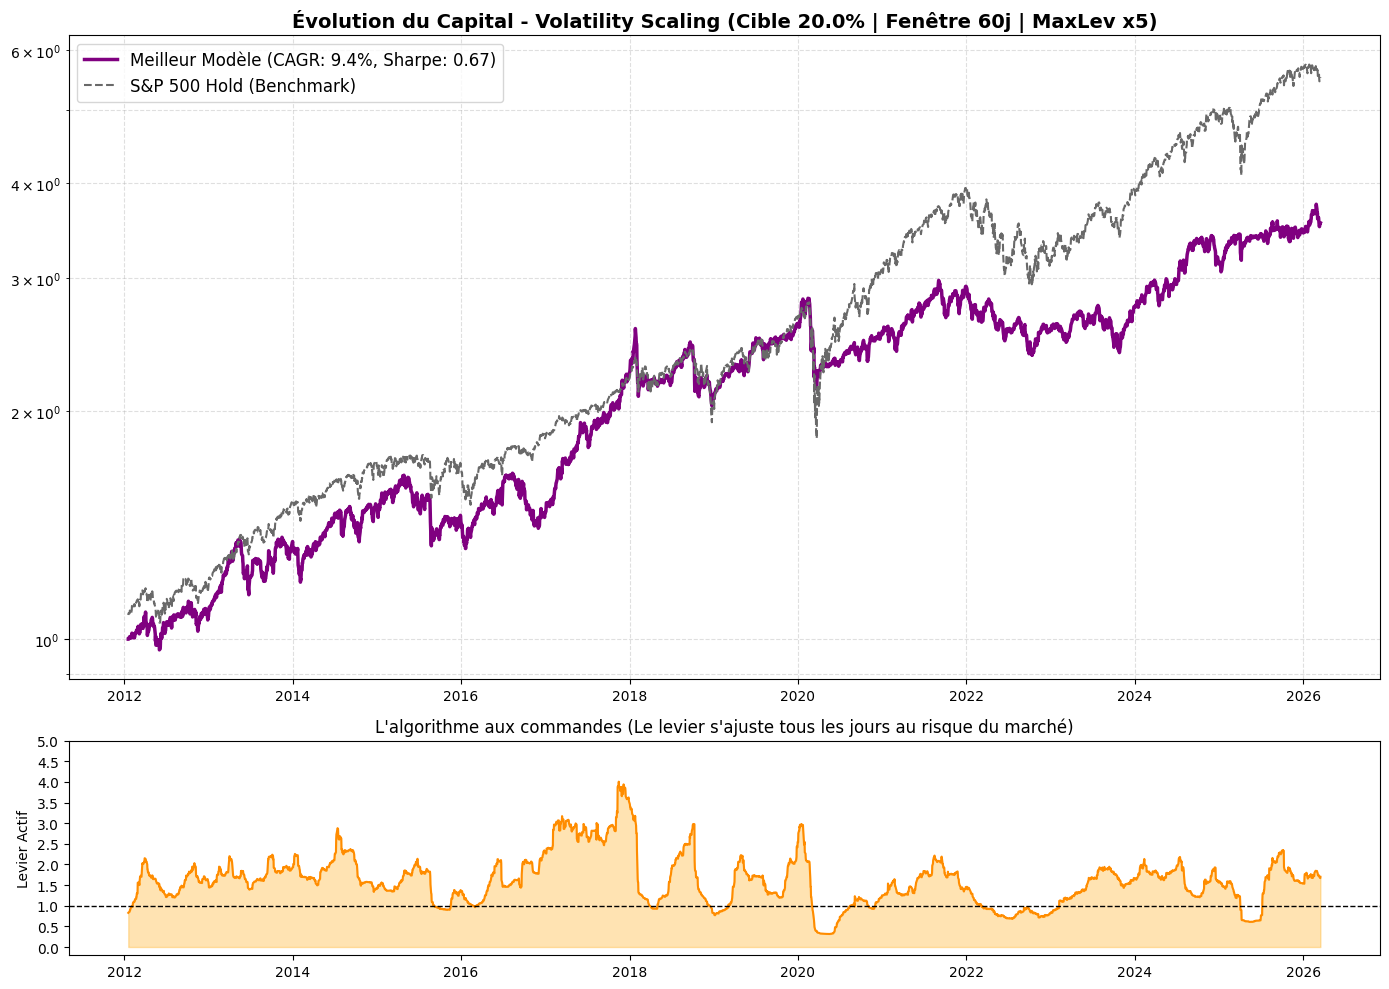

In [27]:
import pandas as pd
import numpy as np
import yfinance as yf
import itertools
import matplotlib.pyplot as plt

# ==========================================
# 1. TÉLÉCHARGEMENT DES DONNÉES
# ==========================================
def fetch_volatility_data():
    print("📥 Téléchargement des données (ACWV et S&P 500)...")
    sp500 = yf.download('^GSPC', start='2000-01-01', end='2026-03-18', progress=False)['Close']
    etf = yf.download('ACWV', start='2000-01-01', end='2026-03-18', progress=False)['Close']
    
    if isinstance(sp500, pd.DataFrame): sp500 = sp500.iloc[:, 0]
    if isinstance(etf, pd.DataFrame): etf = etf.iloc[:, 0]
        
    df = pd.DataFrame({'SP500': sp500, 'ETF': etf}).dropna().reset_index()
    df.columns = ['date', 'SP500', 'ETF']
    print(f"✅ Données prêtes : {len(df)} jours de cotation.\n")
    return df

# ==========================================
# 2. MOTEUR DE BACKTEST : VOLATILITY SCALING
# ==========================================
def run_volatility_scaling_backtest(df, target_vol, vol_window, max_leverage, margin_rate=0.04):
    data = df.copy()
    
    data['SP500_Ret'] = data['SP500'].pct_change()
    data['ETF_Ret'] = data['ETF'].pct_change()
    
    # Calcul de la volatilité glissante annualisée
    data['Market_Vol'] = data['SP500_Ret'].rolling(window=vol_window).std() * np.sqrt(252)
    
    # Levier = Volatilité Cible / Volatilité Actuelle
    data['Raw_Leverage'] = target_vol / data['Market_Vol']
    data['Target_Weight'] = data['Raw_Leverage'].clip(lower=0, upper=max_leverage)
    
    # Calculs Financiers
    data['Weight_Prev'] = data['Target_Weight'].shift(1).fillna(0)
    data['Strat_Gross'] = data['Weight_Prev'] * data['ETF_Ret']
    
    data['Borrowed_Weight'] = np.maximum(0, data['Weight_Prev'] - 1.0)
    data['Daily_Margin_Cost'] = data['Borrowed_Weight'] * (margin_rate / 252)
    
    data['Net_Return'] = data['Strat_Gross'] - data['Daily_Margin_Cost']
    
    data = data.dropna(subset=['Net_Return', 'Market_Vol'])
    data['Capital'] = (1 + data['Net_Return']).cumprod()
    
    if data.empty: return data, 0.0, 0.0, 0.0
        
    final_cap = data['Capital'].iloc[-1]
    n_years = len(data) / 252
    cagr = (final_cap ** (1 / n_years)) - 1 if final_cap > 0 else -1.0
    max_dd = ((data['Capital'] - data['Capital'].cummax()) / data['Capital'].cummax()).min()
    
    mean_ret = data['Net_Return'].mean()
    std_ret = data['Net_Return'].std()
    sharpe = (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else 0.0
    
    return data, cagr, max_dd, sharpe

# ==========================================
# 3. LANCEMENT DE L'OPTIMISATION EN GRILLE
# ==========================================
df_vol = fetch_volatility_data()

# 🛠️ TES PARAMÈTRES DYNAMIQUES
param_grid = {
    'target_vol': [0.10, 0.15, 0.20],    # Cible de risque : 10% (Défensif), 15% (Neutre), 20% (Agressif)
    'vol_window': [10, 20, 60],          # Fenêtre d'observation de la panique
    'max_leverage': [2.0, 2.5, 3.0, 4, 5]      # Plafond d'endettement
}

keys, values = zip(*param_grid.items())
combinations = list(itertools.product(*values))

print(f"🚀 Lancement de l'optimisation sur {len(combinations)} scénarios...")
print("Critère de classement : Maximisation du Ratio de Sharpe\n")

results_list = []
dfs_dict = {}

for t_vol, v_win, max_lev in combinations:
    res_df, cagr, max_dd, sharpe = run_volatility_scaling_backtest(
        df_vol, target_vol=t_vol, vol_window=v_win, max_leverage=max_lev, margin_rate=0.04
    )
    
    config_name = f"Cible {t_vol*100}% | Fenêtre {v_win}j | MaxLev x{max_lev}"
    dfs_dict[config_name] = res_df
    
    results_list.append({
        "Target_Vol": t_vol, "Vol_Window": v_win, "Max_Lev": max_lev,
        "CAGR": cagr, "Max Drawdown": max_dd, "Sharpe Ratio": sharpe,
        "Config_Name": config_name
    })

# Classement par le meilleur Ratio de Sharpe
best_strats = pd.DataFrame(results_list).sort_values(by='CAGR', ascending=False)
display(best_strats.head(10))

# ==========================================
# 4. GRAPHIQUE DE LA MEILLEURE STRATÉGIE
# ==========================================
best_config = best_strats.iloc[0]
best_name = best_config['Config_Name']
best_df = dfs_dict[best_name]

print(f"\n🏆 MEILLEURE CONFIGURATION TROUVÉE : {best_name}")

# Benchmark S&P 500
bench_df = df_vol.copy().dropna()
bench_df['SP500_Return'] = bench_df['SP500'].pct_change()
bench_df['SP500_Capital'] = (1 + bench_df['SP500_Return'].fillna(0)).cumprod()
bench_df = bench_df.loc[bench_df['date'] >= best_df['date'].iloc[0]]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Capital
ax1.plot(best_df['date'], best_df['Capital'], color='purple', linewidth=2.5, 
         label=f"Meilleur Modèle (CAGR: {best_config['CAGR']*100:.1f}%, Sharpe: {best_config['Sharpe Ratio']:.2f})")
ax1.plot(bench_df['date'], bench_df['SP500_Capital'], color='dimgray', 
         linewidth=1.5, linestyle='--', label="S&P 500 Hold (Benchmark)")
ax1.set_yscale('log')
ax1.set_title(f"Évolution du Capital - Volatility Scaling ({best_name})", fontsize=14, fontweight='bold')
ax1.grid(True, which="both", ls="--", alpha=0.4)
ax1.legend(loc='upper left', fontsize=12)

# Levier dynamique
ax2.plot(best_df['date'], best_df['Target_Weight'], color='darkorange', linewidth=1.5)
ax2.fill_between(best_df['date'], 0, best_df['Target_Weight'], color='orange', alpha=0.3)
ax2.axhline(y=1.0, color='black', linestyle='--', linewidth=1)
ax2.set_title("L'algorithme aux commandes (Le levier s'ajuste tous les jours au risque du marché)", fontsize=12)
ax2.set_yticks(np.arange(0, best_config['Max_Lev'] + 0.5, 0.5))
ax2.set_ylabel("Levier Actif")

plt.tight_layout()
plt.show()